# C-Reactive Protein EDA
This notebook is similar to *hemoglobin_eda.ipynb* and *sedimentation_rate_eda.ipynb* in the following sense: the objective is to compare c-reactive protein labs (`itemid` = 50889) of patients with kidney disease to c-reactive protein labs of patients with healthy kidneys. The c-reactive protein lab is another measure of inflammation, which is a metaphor for how much illness there is to fight off in the body. As in the two notebooks mentioned previously, this comparison is being made to show that the two groups of patients are similar. Thus, the only feature that distinguishes the two sets of patients is the presence or absence of kidney disease. 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The next two cells begin the comparison by extracting c-reactive protein labs for patients with kidney disease. 

In [8]:
kidney_disease_data = pd.read_csv('../Data/trimmed_kidney_disease_random_1000_patients.csv.gz',
                                 compression = 'gzip')
kidney_disease_data.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,268992,10015860,22413744.0,1702357,50853,NaN,2191-01-27 06:25:00,2191-01-28 13:25:00,___,11.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
1,1388766,10097612,NaN,97048763,50853,P19GXG,2159-05-17 12:35:00,2159-05-18 10:31:00,___,16.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
2,1952705,10132512,NaN,72063012,50853,P30YWU,2178-02-12 08:16:00,2178-02-13 09:42:00,___,32.0,ng/mL,30.0,60.0,NaN,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
3,1952726,10132512,NaN,77832825,50853,P30YWU,2178-05-16 07:55:00,2178-05-18 08:13:00,___,42.0,ng/mL,30.0,60.0,NaN,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
4,1952831,10132512,NaN,30613615,50853,P84CA4,2179-03-09 14:36:00,2179-03-10 13:31:00,___,33.0,ng/mL,30.0,60.0,NaN,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...


In [9]:
c_reactive_protein_id = 50889
kidney_disease_data_reduced = kidney_disease_data.loc[kidney_disease_data['itemid'] == c_reactive_protein_id]
kidney_disease_ids = list(set(kidney_disease_data_reduced['subject_id']))
protein_kidney_disease = pd.DataFrame(columns = ['c-reactive protein'])
for patient in kidney_disease_ids:
    earliest_lab_date = kidney_disease_data_reduced.loc[kidney_disease_data_reduced['subject_id'] == patient, 'charttime'].min()
    protein_kidney_disease.loc[patient] = kidney_disease_data_reduced.loc[(kidney_disease_data_reduced['subject_id'] == patient) & (kidney_disease_data_reduced['charttime'] == earliest_lab_date), 'valuenum'].values
protein_kidney_disease.head()

,c-reactive protein
12433420,13.5
14161935,5.3
14870544,NaN
13576210,15.0
15939603,3.7


The next two cells extract the c-reactive protein labs for patients with healthy kidneys.

In [10]:
normal_kidney_data = pd.read_csv('../Data/trimmed_normal_kidney_patients.csv.gz',
                                compression = 'gzip')
normal_kidney_data.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,656869,10041351,28202624.0,87960306,50853,NaN,2117-09-24 06:24:00,2117-09-26 14:57:00,20,20.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NaN
1,206675,10012703,NaN,65289690,50853,P134DE,2184-02-27 13:45:00,2184-02-28 10:30:00,___,4.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
2,206771,10012703,NaN,45239687,50853,P134DE,2184-06-05 10:30:00,2184-06-08 10:45:00,___,24.0,ng/mL,30.0,60.0,abnormal,STAT,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
3,680714,10043423,NaN,40263589,50853,P941BA,2140-07-04 15:15:00,2140-07-06 15:11:00,8,8.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NaN
4,255932,10014790,NaN,89220377,50853,P61084,2171-10-26 14:35:00,2171-10-26 19:17:00,___,46.0,ng/mL,30.0,60.0,NaN,ROUTINE,"Effective ___, values will be reported from th..."


In [11]:
normal_kidney_data_reduced = normal_kidney_data.loc[normal_kidney_data['itemid'] == c_reactive_protein_id]
normal_kidney_ids = list(set(normal_kidney_data_reduced['subject_id']))
protein_normal_kidney = pd.DataFrame(columns = ['c-reactive protein'])
for patient in normal_kidney_ids:
    earliest_lab_date = normal_kidney_data_reduced.loc[normal_kidney_data_reduced['subject_id'] == patient, 'charttime'].min()
    protein_normal_kidney.loc[patient] = normal_kidney_data_reduced.loc[(normal_kidney_data_reduced['subject_id'] == patient) & (normal_kidney_data_reduced['charttime'] == earliest_lab_date), 'valuenum'].values
protein_normal_kidney.head()

,c-reactive protein
10060803,2.4
10013700,11.2
10033159,155.1
10005001,7.5
10002443,8.2


The next cell concludes the notebook by using the c-reactive protein lab data to create a histogram for both groups of patients. Notice the two histograms align fairly well, with the exception being that a larger number of patients with healthy kidneys fall into the first bin. The number of patients in both groups that have a c-reactive protein lab reading is calculated and output following the histogram.

The number of kidney patients that have a c-reactive protein reading is 324 

The number of kidney patients that have a c-reactive protein reading > 150 is 26 

The number of non-kidney that have a c-reactive protein reading is 219 

The number of non-kidney patients that have a c-reactive protein readings > 150 is 13


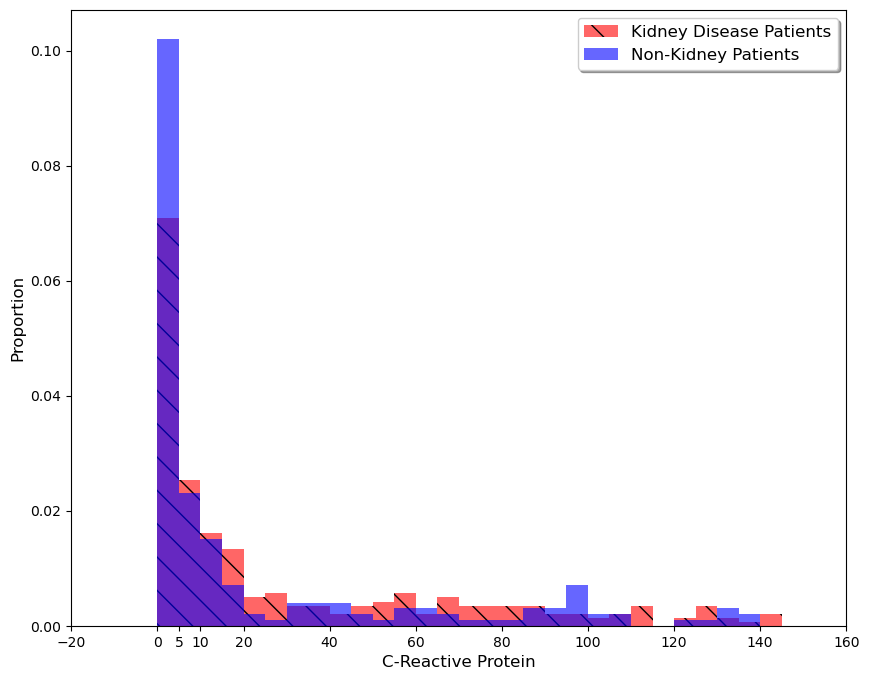

In [12]:
plt.figure(figsize = (10, 8))
plt.hist(protein_kidney_disease['c-reactive protein'],
        color = 'red',
        hatch = '\\',
        alpha = 0.6,
        density = True,
        bins = np.arange(0, 150, 5),
        label = 'Kidney Disease Patients')
plt.hist(protein_normal_kidney['c-reactive protein'],
        color = 'blue',
        alpha = 0.6,
        density = True,
        bins = np.arange(0, 150, 5),
        label = 'Non-Kidney Patients')
plt.xlabel('C-Reactive Protein', 
          fontsize = 12)
plt.ylabel('Proportion',
          fontsize = 12)
plt.legend(fontsize = 12,
          loc = 'upper right',
          fancybox = True,
          shadow = True)
x_tick_locations, x_tick_labels = plt.xticks()
all_ticks = np.append(x_tick_locations, [5, 10])
plt.xticks(all_ticks)
print('The number of kidney patients that have a c-reactive protein reading is', protein_kidney_disease.shape[0], '\n')
print('The number of kidney patients that have a c-reactive protein reading > 150 is', protein_kidney_disease.loc[protein_kidney_disease['c-reactive protein'] > 150].shape[0], '\n')
print('The number of non-kidney that have a c-reactive protein reading is', protein_normal_kidney.shape[0], '\n')
print('The number of non-kidney patients that have a c-reactive protein readings > 150 is', protein_normal_kidney.loc[protein_normal_kidney['c-reactive protein'] > 150].shape[0])